In [3]:
import os
import re
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from matplotlib import rcParams
import matplotlib.patches as patches
from scipy.optimize import curve_fit, minimize
import os
import glob



#%matplotlib inline

# plot style
rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [16, 6]
rcParams['font.size'] = 22
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 16

from mpl_toolkits.mplot3d import Axes3D  

# to prevent ROOT errors
root_path = "/scratch/elena/root-6.26.04-install"
os.environ["ROOTSYS"] = root_path
os.environ["PYTHONPATH"] = f"{root_path}/lib:{os.environ.get('PYTHONPATH', '')}"
os.environ["LD_LIBRARY_PATH"] = f"{root_path}/lib:{os.environ.get('LD_LIBRARY_PATH', '')}"
sys.path.append(f"{root_path}/lib")

#set variables so functions_bonsai can locate required files
os.environ["WCSIM_BUILD_DIR"] = "/scratch/elena/wcsim-install"
os.environ["BONSAIDIR"] = "/scratch/elena/bonsai"


sys.path.append("/scratch/elena/9Li/scripts")
import functions_bonsai
import functions_multilateration

In [4]:
RUNS = [1846, 1848, 1928, 1930, 1932, 1934, 1935, 1936, 1937, 1938, 1939, 1941]
BASE_DIR = "/scratch/elena/9Li/results"

def get_beam_momentum(run_id):
    if run_id in [1846, 1848]:
        return "-340 MeV/c"
    else:
        return "-260 MeV/c"


before_fv_summary = []
after_fv_summary = []


for run in RUNS:
    run_folder = f"{BASE_DIR}/run{run}/processed"
    momentum = get_beam_momentum(run)
    
    #count BEFORE FV
    refined_pattern = os.path.join(run_folder, "Refine_Li9_clusters_chunk*_BKG.pkl")
    refined_files = glob.glob(refined_pattern)
    
    total_before = 0
    for f in refined_files:
        try:
            df_chunk = pd.read_pickle(f)
            total_before += len(df_chunk)
        except Exception:
            pass #handle empty or corrupted files safely
            
    before_fv_summary.append({
        "Run": f"Run {run}",
        "Beam Momentum": momentum,
        "Clusters (Before FV)": total_before
    })
    
    #count AFTER FV 
    final_fv_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}_BKG.pkl")
    
    total_after = 0
    if os.path.exists(final_fv_file):
        try:
            df_final = pd.read_pickle(final_fv_file)
            total_after = len(df_final)
        except Exception:
            pass
            
    after_fv_summary.append({
        "Run": f"Run {run}",
        "Beam Momentum": momentum,
        "Clusters (Within FV)": total_after
    })

df_before = pd.DataFrame(before_fv_summary)
df_after = pd.DataFrame(after_fv_summary)

print("=" * 60)
print("TABLE 1: BACKGROUND CLUSTER CANDIDATES BEFORE FIDUCIAL VOLUME CUT")
print("=" * 60)
print(df_before.to_string(index=False))

print("\n" + "=" * 60)
print("TABLE 2: BACKGROUND FINAL CLUSTER CANDIDATES WITHIN THE FIDUCIAL VOLUME")
print("=" * 60)
print(df_after.to_string(index=False))

TABLE 1: BACKGROUND CLUSTER CANDIDATES BEFORE FIDUCIAL VOLUME CUT
     Run Beam Momentum  Clusters (Before FV)
Run 1846    -340 MeV/c                 28760
Run 1848    -340 MeV/c                 25502
Run 1928    -260 MeV/c                 80308
Run 1930    -260 MeV/c                122329
Run 1932    -260 MeV/c                101171
Run 1934    -260 MeV/c                 70304
Run 1935    -260 MeV/c                 69064
Run 1936    -260 MeV/c                 54751
Run 1937    -260 MeV/c                 75091
Run 1938    -260 MeV/c                 44792
Run 1939    -260 MeV/c                 77072
Run 1941    -260 MeV/c                 94885

TABLE 2: BACKGROUND FINAL CLUSTER CANDIDATES WITHIN THE FIDUCIAL VOLUME
     Run Beam Momentum  Clusters (Within FV)
Run 1846    -340 MeV/c                   362
Run 1848    -340 MeV/c                   296
Run 1928    -260 MeV/c                   387
Run 1930    -260 MeV/c                   819
Run 1932    -260 MeV/c                   747
Run 19

In [5]:
RUN_TEST = 1932
BASE_DIR = "/scratch/elena/9Li/results"
run_folder = f"{BASE_DIR}/run{RUN_TEST}/processed"


#STAGE 1
original_pattern = os.path.join(run_folder, "Li9_clusters_range(15-50)_chunk*_BKG.pkl")
original_files = sorted(glob.glob(original_pattern))

if original_files:
    print(f"\n[STAGE 1] Found original: {os.path.basename(original_files[0])}")
    try:
        df_orig = pd.read_pickle(original_files[0])
        print("Available columns:")
        print(sorted(list(df_orig.columns)))
    except Exception as e:
        print(f"Error reading Stage 1 file: {e}")
else:
    print("\n[STAGE 1] Warning: No original chunk files found to inspect.")

#STAGE 2
refined_pattern = os.path.join(run_folder, "Refine_Li9_clusters_chunk*_BKG.pkl")
refined_files = sorted(glob.glob(refined_pattern))

if refined_files:
    print(f"\n[STAGE 2] Found Refined file: {os.path.basename(refined_files[0])}")
    try:
        df_ref = pd.read_pickle(refined_files[0])
        print("Available columns:")
        print(sorted(list(df_ref.columns)))
    except Exception as e:
        print(f"Error reading Stage 2 file: {e}")
else:
    print("\n[STAGE 2] Warning: No refined chunk files found to inspect.")

#STAGE 3
final_fv_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{RUN_TEST}_BKG.pkl")

if os.path.exists(final_fv_file):
    print(f"\n[STAGE 3] Found Final FV file: {os.path.basename(final_fv_file)}")
    try:
        df_final = pd.read_pickle(final_fv_file)
        print("Available columns:")
        print(sorted(list(df_final.columns)))
    except Exception as e:
        print(f"Error reading Stage 3 file: {e}")
else:
    print(f"\n[STAGE 3] Warning: The final file '{os.path.basename(final_fv_file)}' does not exist.")


[STAGE 1] Found original: Li9_clusters_range(15-50)_chunk_0_BKG.pkl
Available columns:
['chi2', 'chi2_ndof', 'fit_success', 'hit_charges', 'hit_position_ids', 'hit_slot_ids', 'hit_times_ns', 'nCLusters_in_spill', 'nHits', 'n_hits_used', 'ndof', 'spill_id', 't_rms_ns', 't_window_start_ns', 't_window_start_rel_ns', 'time_rms', 'vertex_x', 'vertex_y', 'vertex_z']

[STAGE 2] Found Refined file: Refine_Li9_clusters_chunk_0_BKG.pkl
Available columns:
['chi2', 'chi2_ndof', 'fit_success', 'hit_charges', 'hit_position_ids', 'hit_slot_ids', 'hit_times_ns', 'nCLusters_in_spill', 'nHits', 'n_hits_used', 'ndof', 'nhits_fine', 'spill_id', 't_rms_fine', 't_rms_ns', 't_window_start_ns', 't_window_start_rel_ns', 'time_rms', 'v_x_fine', 'v_y_fine', 'v_z_fine', 'vertex_x', 'vertex_y', 'vertex_z']

[STAGE 3] Found Final FV file: Final_FV_Li9_clusters_run1932_BKG.pkl
Available columns:
['chi2', 'chi2_ndof', 'fit_success', 'hit_charges', 'hit_position_ids', 'hit_slot_ids', 'hit_times_ns', 'nCLusters_in_spi

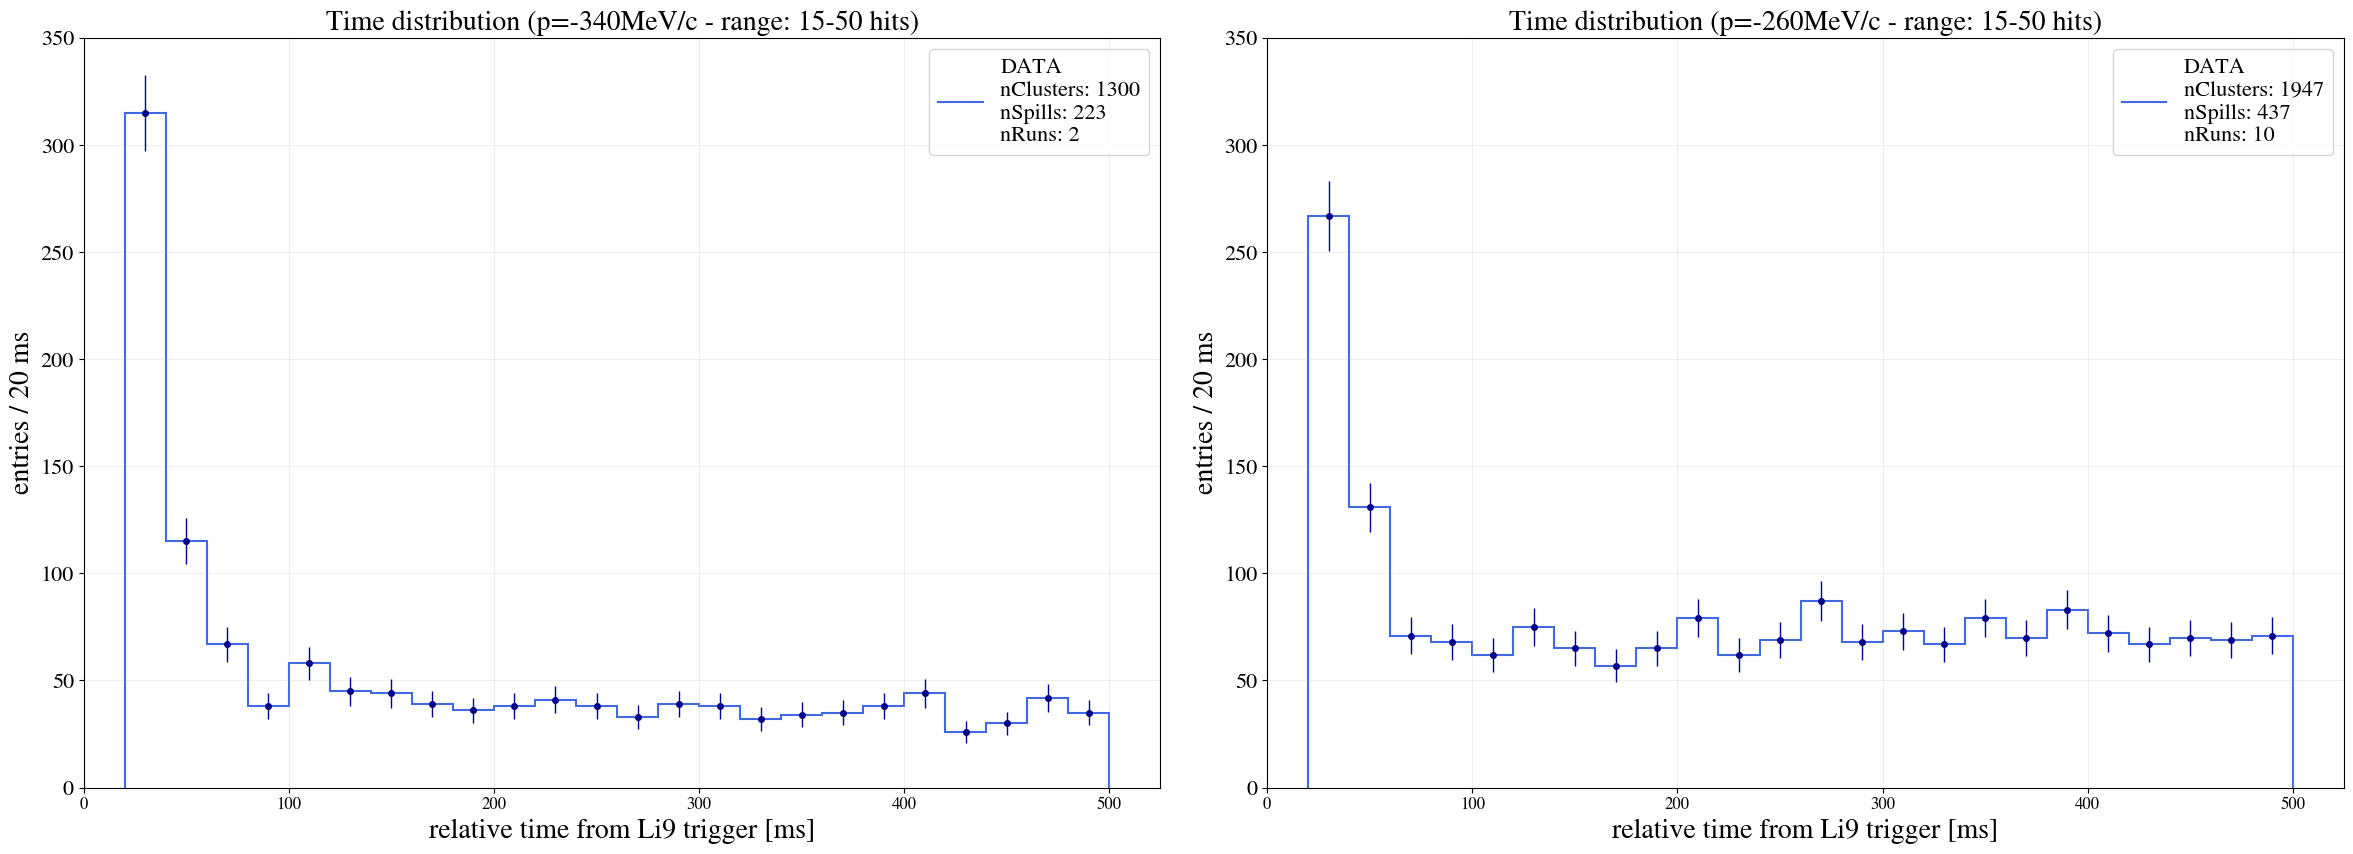

In [50]:
momentum_map = {run: get_beam_momentum(run) for run in RUNS}

dfs_340 = []
dfs_260 = []

for run in RUNS:
    run_folder = f"{BASE_DIR}/run{run}/processed"
    final_fv_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}.pkl")
    
    if os.path.exists(final_fv_file):
        try:
            df = pd.read_pickle(final_fv_file)
            if not df.empty:
                df['origin_run'] = run
                if momentum_map[run] == "-340 MeV/c":
                    dfs_340.append(df)
                else:
                    dfs_260.append(df)
        except Exception as e:
            print(f"Error loading {final_fv_file}: {e}")

df_340_combined = pd.concat(dfs_340, ignore_index=True) if dfs_340 else pd.DataFrame()
df_260_combined = pd.concat(dfs_260, ignore_index=True) if dfs_260 else pd.DataFrame()


# PLOTS

rcParams['figure.figsize'] = [24, 9]
fig, axs = plt.subplots(1, 2, sharey=False)

bin_width = 20  # ms
bins = np.arange(20, 500 + bin_width, bin_width)
time_column = "t_window_start_rel_ns" 

plot_configs = [
    {
        "df": df_340_combined,
        "ax": axs[0],
        "title": "Time distribution (p=-340MeV/c - range: 15-50 hits)",
        "num_runs": len(dfs_340),
        #"const_line": 45.98  # Constant line value for 340 MeV/c
    },
    {
        "df": df_260_combined,
        "ax": axs[1],
        "title": "Time distribution (p=-260MeV/c - range: 15-50 hits)",
        "num_runs": len(dfs_260),
        #"const_line": 45.98  # Adjust this value if the 260 MeV/c background baseline differs
    }
]

for config in plot_configs:
    df_plot = config["df"]
    ax = config["ax"]
    
    if df_plot.empty:
        ax.text(0.5, 0.5, "No Data within FV", transform=ax.transAxes, ha="center")
        ax.set_title(config["title"])
        continue

    if time_column not in df_plot.columns:
        print(f"Error: Column '{time_column}' not found.")
        continue

    # UNIT CONVERSION CRITICAL FIX: Convert 't_window_start_rel_ns' from ns to ms
    time_in_ms = df_plot[time_column] / 1e6

    # Apply the exact histogram logic with the 20 ms offset shift
    counts, bin_edges = np.histogram(time_in_ms + 20, bins=bins)
    
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    errors = np.sqrt(np.maximum(counts, 1))

    # Draw step histogram profile
    ax.stairs(counts,bin_edges,color="royalblue",linewidth=1.5,
        label=(
            f"DATA\n"
            f"nClusters: {len(df_plot)}\n"
            f"nSpills: {df_plot['spill_id'].nunique() if 'spill_id' in df_plot.columns else 'N/A'}\n"
            f"nRuns: {config['num_runs']}"
        ),
    )

    #error data points
    ax.errorbar(bin_centers, counts, yerr=errors, fmt="o", color="darkblue", markersize=4, capsize=0, elinewidth=1, ls="none")

    # Horizontal baseline restriction strictly bounded between 20 ms and 500 ms
    #ax.hlines(y=config["const_line"], xmin=20, xmax=500, color="red", linewidth=2.5, label=f"C = {config['const_line']}")

   
    ax.set_title(config["title"])
    ax.set_xlabel("relative time from Li9 trigger [ms]")
    ax.set_ylabel(f"entries / {bin_width} ms")
    ax.grid(True, which="both", linestyle="-", alpha=0.2)
    

    ax.set_yscale("linear")
    ax.set_xlim(0, 525)
    ax.set_ylim(0, 350)
    
    ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

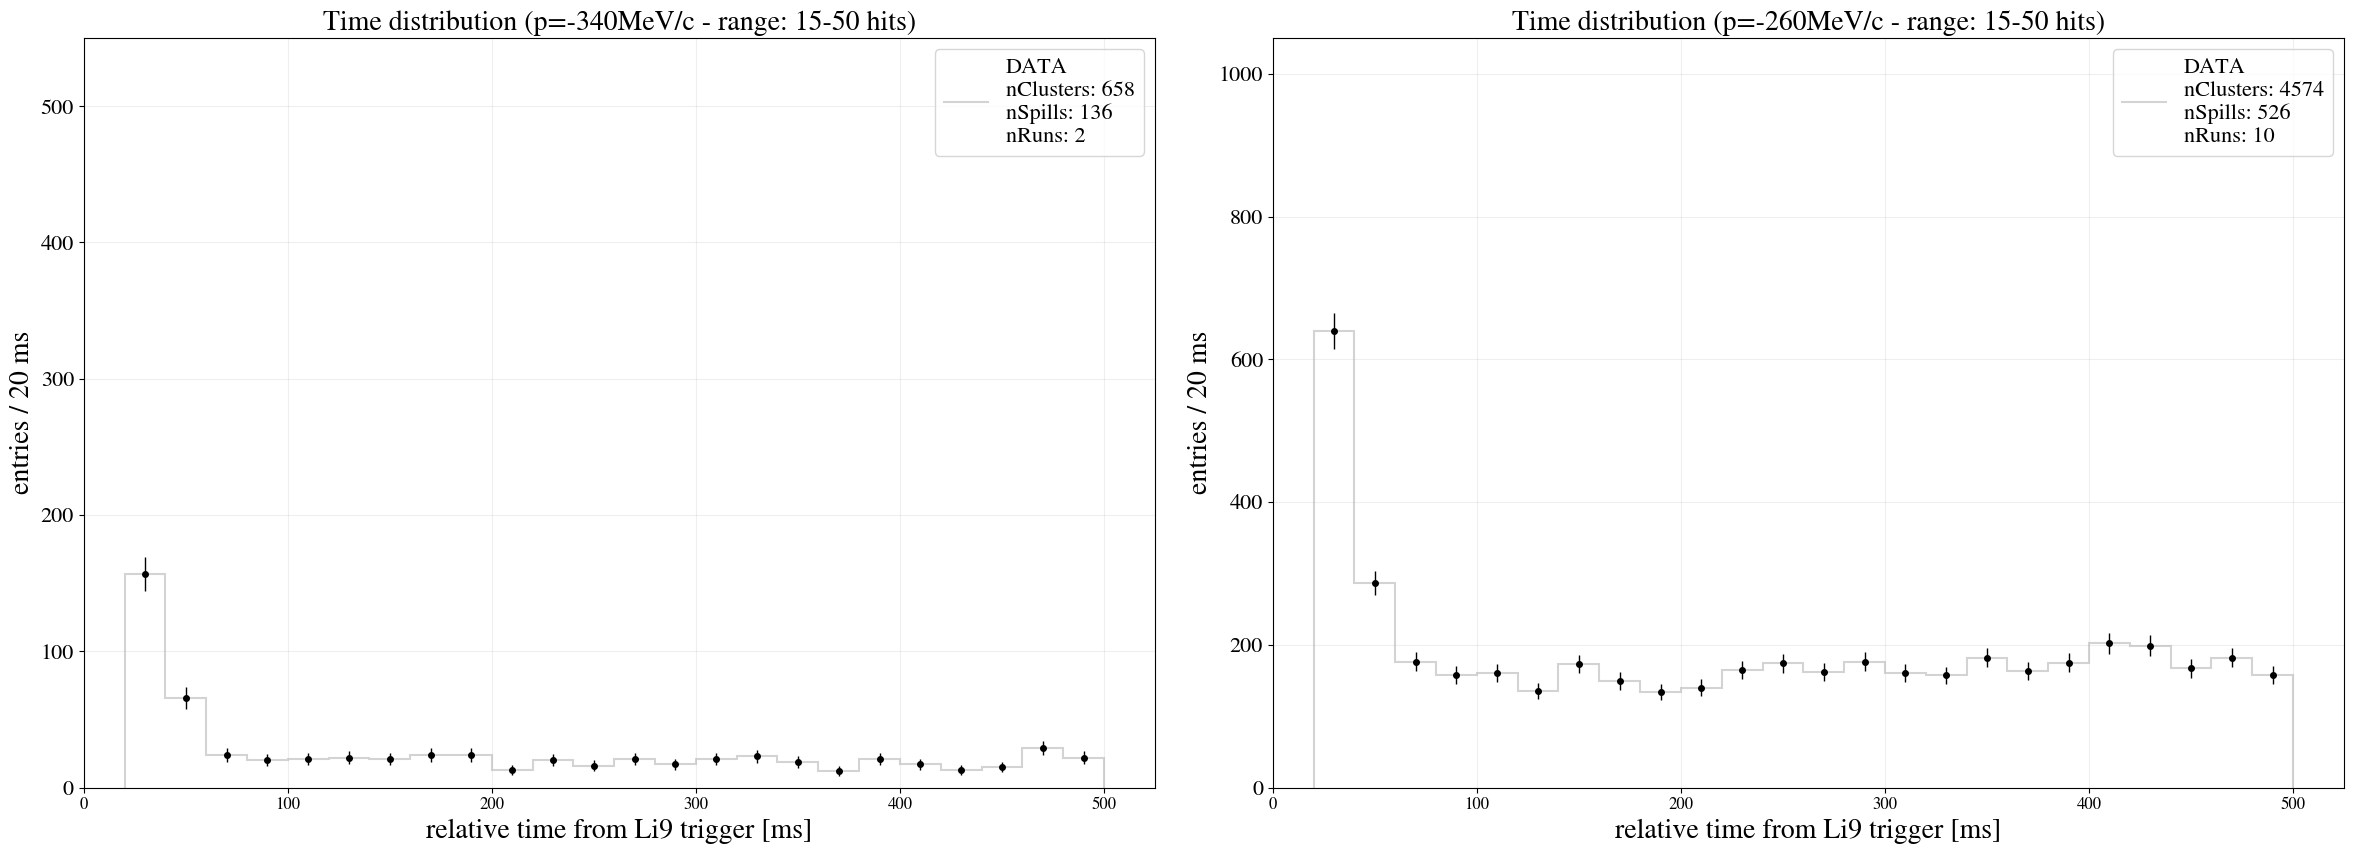

In [7]:
#PLOT ylim fixed!

rcParams['figure.figsize'] = [24, 9]
fig, axs = plt.subplots(1, 2, sharey=False)

bin_width = 20  # ms
bins = np.arange(20, 500 + bin_width, bin_width)
time_column = "t_window_start_rel_ns" 

plot_configs = [
    {
        "df": df_340_combined,
        "ax": axs[0],
        "title": "Time distribution (p=-340MeV/c - range: 15-50 hits)",
        "num_runs": len(dfs_340),
        "y_max": 550  #fixed lim  
    },

    {
        "df": df_260_combined,
        "ax": axs[1],
        "title": "Time distribution (p=-260MeV/c - range: 15-50 hits)",
        "num_runs": len(dfs_260),
        "y_max": 1050  #fixed lim
    }
]

for config in plot_configs:
    df_plot = config["df"]
    ax = config["ax"]
    
    if df_plot.empty:
        ax.text(0.5, 0.5, "No Data Within FV", transform=ax.transAxes, ha="center")
        ax.set_title(config["title"])
        continue

    if time_column not in df_plot.columns:
        print(f"Error: Column '{time_column}' not found.")
        continue

    time_in_ms = df_plot[time_column] / 1e6   #unit conversion

    counts, bin_edges = np.histogram(time_in_ms + 20, bins=bins)
    
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    errors = np.sqrt(np.maximum(counts, 1))


    ax.stairs(counts,bin_edges,color="lightgray",linewidth=1.5,
        label=(
            f"DATA\n"
            f"nClusters: {len(df_plot)}\n"
            f"nSpills: {df_plot['spill_id'].nunique() if 'spill_id' in df_plot.columns else 'N/A'}\n"
            f"nRuns: {config['num_runs']}"
        ),
    )
    ax.errorbar(bin_centers, counts, yerr=errors, fmt="o", color="black", markersize=4, capsize=0, elinewidth=1, ls="none")

    ax.set_title(config["title"])
    ax.set_xlabel("relative time from Li9 trigger [ms]")
    ax.set_ylabel(f"entries / {bin_width} ms")
    ax.grid(True, which="both", linestyle="-", alpha=0.2)
    
    ax.set_yscale("linear")
    ax.set_xlim(0, 525)
    ax.set_ylim(0, config["y_max"]) #fixed ylim
    
    ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

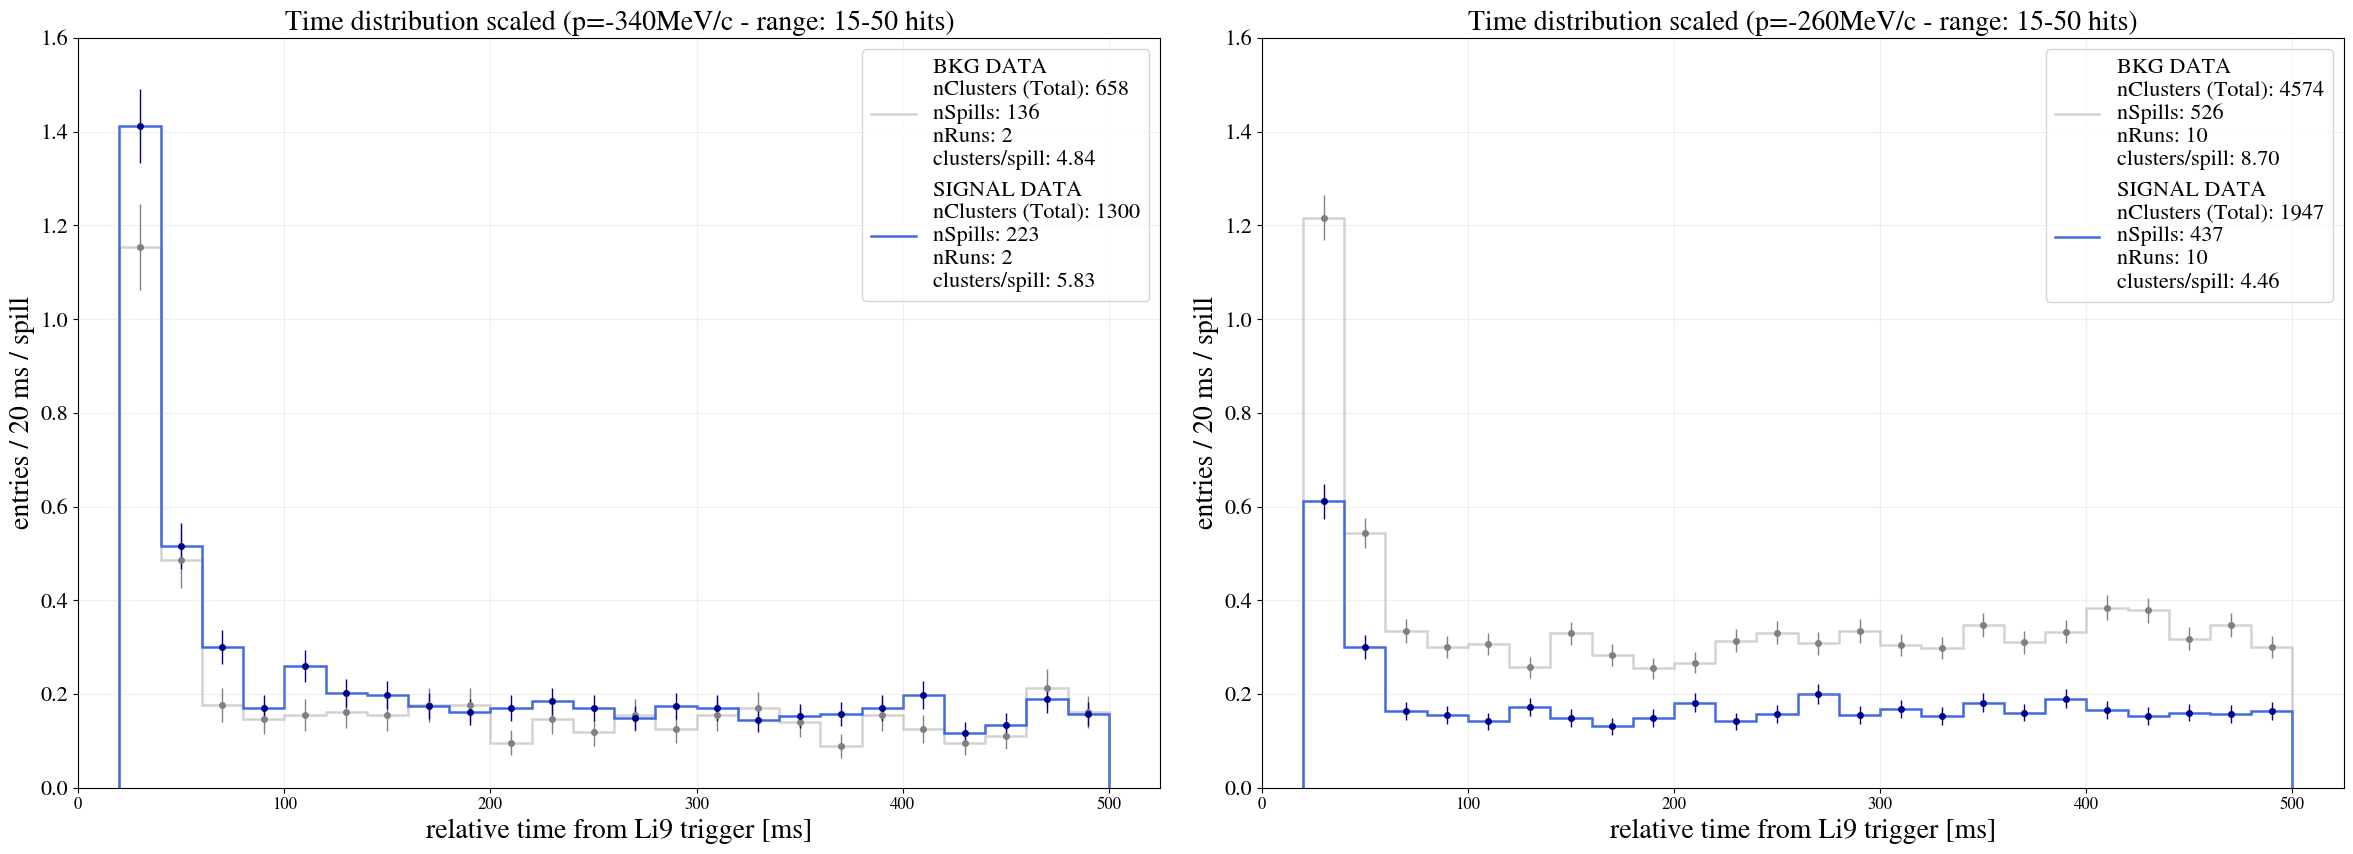

In [49]:
dfs_340_sig = []
dfs_340_bkg = []
dfs_260_sig = []
dfs_260_bkg = []


for run in RUNS:
    run_folder = f"{BASE_DIR}/run{run}/processed"
    
    sig_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}.pkl")
    bkg_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}_BKG.pkl")
    
    #load signal data
    if os.path.exists(sig_file):
        try:
            df_sig = pd.read_pickle(sig_file)
            if not df_sig.empty:
                df_sig['origin_run'] = run
                if momentum_map[run] == "-340 MeV/c":
                    dfs_340_sig.append(df_sig)
                else:
                    dfs_260_sig.append(df_sig)
        except Exception as e:
            print(f"Error loading Signal file {sig_file}: {e}")

    #load BKG
    if os.path.exists(bkg_file):
        try:
            df_bkg = pd.read_pickle(bkg_file)
            if not df_bkg.empty:
                df_bkg['origin_run'] = run
                if momentum_map[run] == "-340 MeV/c":
                    dfs_340_bkg.append(df_bkg)
                else:
                    dfs_260_bkg.append(df_bkg)
        except Exception as e:
            print(f"Error loading BKG file {bkg_file}: {e}")

#Safe df concatenation 
df_340_sig_comb = pd.concat(dfs_340_sig, ignore_index=True) if dfs_340_sig else pd.DataFrame()
df_340_bkg_comb = pd.concat(dfs_340_bkg, ignore_index=True) if dfs_340_bkg else pd.DataFrame()
df_260_sig_comb = pd.concat(dfs_260_sig, ignore_index=True) if dfs_260_sig else pd.DataFrame()
df_260_bkg_comb = pd.concat(dfs_260_bkg, ignore_index=True) if dfs_260_bkg else pd.DataFrame()


# PLOT
rcParams['figure.figsize'] = [24, 9]
fig, axs = plt.subplots(1, 2, sharey=False)

bin_width = 20  # ms
bins = np.arange(20, 500 + bin_width, bin_width)
time_column = "t_window_start_rel_ns" 

# Ajustamos las alturas máximas visuales ya que los valores por spill serán notablemente menores
plot_configs = [
    {
        "df_sig": df_340_sig_comb,
        "df_bkg": df_340_bkg_comb,
        "ax": axs[0],
        "title": "Time distribution scaled (p=-340MeV/c - range: 15-50 hits)",
        "num_runs_sig": len(dfs_340_sig),
        "num_runs_bkg": len(dfs_340_bkg),
        "y_max": 2.5  
    },
    {
        "df_sig": df_260_sig_comb,
        "df_bkg": df_260_bkg_comb,
        "ax": axs[1],
        "title": "Time distribution scaled (p=-260MeV/c - range: 15-50 hits)",
        "num_runs_sig": len(dfs_260_sig),
        "num_runs_bkg": len(dfs_260_bkg),
        "y_max": 5.0  
    }
]

for config in plot_configs:
    ax = config["ax"]
    ax.set_title(config["title"])
    
    # --- SUB-PLOTTER: FUNCIÓN INTERNA MODIFICADA PARA ESCALAR POR SPILL ---
    def plot_sample(df_plot, sample_label, hist_color, marker_color, num_runs):
        if df_plot.empty or (time_column not in df_plot.columns):
            return False
            
        time_in_ms = df_plot[time_column] / 1e6

        counts, bin_edges = np.histogram(time_in_ms + 20, bins=bins)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        # Identificar número de spills únicos para normalizar
        n_spills = df_plot['spill_id'].nunique() if 'spill_id' in df_plot.columns else 1
        
        # --- LÓGICA DE ESCALADO ---
        counts_scaled = counts / n_spills
        # Error de Poisson escalado: sqrt(N) / nSpills
        errors_scaled = np.sqrt(np.maximum(counts, 1)) / n_spills

        # Label con información clara
        label_text = (
            f"{sample_label}\n"
            f"nClusters (Total): {len(df_plot)}\n"
            f"nSpills: {n_spills}\n"
            f"nRuns: {num_runs}\n"
            f"clusters/spill: {len(df_plot)/n_spills:.2f}"
        )

        ax.stairs(counts_scaled, bin_edges, color=hist_color, linewidth=1.8, label=label_text)
        ax.errorbar(bin_centers, counts_scaled, yerr=errors_scaled, fmt="o", color=marker_color, markersize=4, capsize=0, elinewidth=1, ls="none")
        return True


    
    # plot BACKGROUND 
    has_bkg = plot_sample(
        config["df_bkg"], "BKG DATA", 
        hist_color="lightgray", marker_color="gray", 
        num_runs=config["num_runs_bkg"]
    )

    # plot SIGNAL
    has_sig = plot_sample(
        config["df_sig"], "SIGNAL DATA", 
        hist_color="royalblue", marker_color="darkblue", 
        num_runs=config["num_runs_sig"]
    )

    if not has_sig and not has_bkg:
        ax.text(0.5, 0.5, "No Data within FV (signal or BKG)", transform=ax.transAxes, ha="center")
        continue

    ax.set_xlabel("relative time from Li9 trigger [ms]")
    ax.set_ylabel(f"entries / {bin_width} ms / spill") # Eje Y modificado para reflejar la normalización
    ax.grid(True, which="both", linestyle="-", alpha=0.2)
    
    ax.set_yscale("linear")
    ax.set_xlim(0, 525)
    
    # Si las alturas por defecto se quedan cortas, ajustamos dinámicamente
    ax.set_ylim(0, 1.60)
    
    ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_302814/4166983912.py:68: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_r1, pcov_r1 = curve_fit(


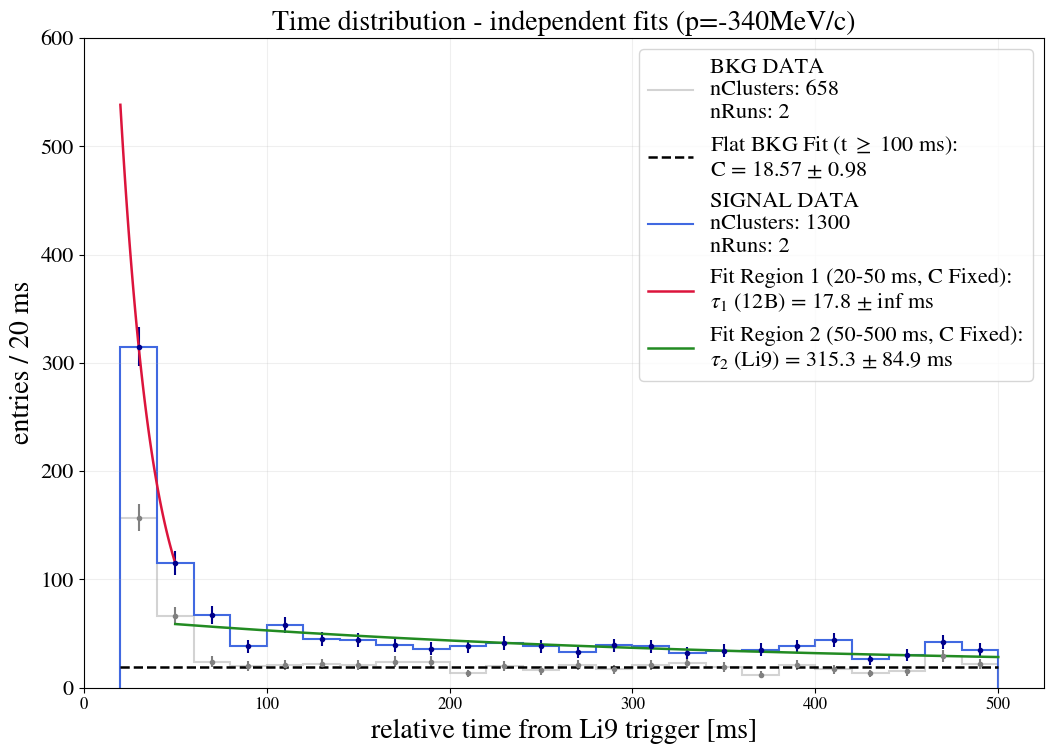

In [25]:
RUNS_340 = [1846, 1848]   #only this Beam p (from the previous step)
dfs_340_sig = []
dfs_340_bkg = []

for run in RUNS_340:
    run_folder = f"{BASE_DIR}/run{run}/processed"
    sig_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}.pkl")
    bkg_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}_BKG.pkl")
    
    if os.path.exists(sig_file):
        df_sig = pd.read_pickle(sig_file)
        if not df_sig.empty:
            df_sig['origin_run'] = run
            dfs_340_sig.append(df_sig)
            
    if os.path.exists(bkg_file):
        df_bkg = pd.read_pickle(bkg_file)
        if not df_bkg.empty:
            df_bkg['origin_run'] = run
            dfs_340_bkg.append(df_bkg)

df_sig_total = pd.concat(dfs_340_sig, ignore_index=True) if dfs_340_sig else pd.DataFrame()
df_bkg_total = pd.concat(dfs_340_bkg, ignore_index=True) if dfs_340_bkg else pd.DataFrame()


bin_width = 20 #ms
bins = np.arange(20, 500 + bin_width, bin_width)
time_column = "t_window_start_rel_ns"

times_sig_ms = (df_sig_total[time_column] / 1e6) + 20  #offset 20ms
times_bkg_ms = (df_bkg_total[time_column] / 1e6) + 20

counts_sig, bin_edges = np.histogram(times_sig_ms, bins=bins)
counts_bkg, _ = np.histogram(times_bkg_ms, bins=bins)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
errors_sig = np.sqrt(np.maximum(counts_sig, 1))
errors_bkg = np.sqrt(np.maximum(counts_bkg, 1))


# FIT 1 ---> flat BKG --> C

t_cut_bkg = 100  #excluyendo primeros bins 
mask_bkg_fit = bin_centers >= t_cut_bkg

def flat_func(t, c):
    return np.full_like(t, c)

popt_bkg, pcov_bkg = curve_fit(
    flat_func, 
    bin_centers[mask_bkg_fit], 
    counts_bkg[mask_bkg_fit], 
    sigma=errors_bkg[mask_bkg_fit],
    p0=[np.mean(counts_bkg[mask_bkg_fit])]
)
C_const = popt_bkg[0]
C_err = np.sqrt(pcov_bkg[0, 0])
#print(f"C = {C_const:.2f} ± {C_err:.2f}")

# FIT 2 --> curve fit --> 2 independientes con C fija para ambos

def exp_with_c(t, Amplitude, tau):
    return Amplitude * np.exp(-t / tau) + C_const

#region (20-50 ms)
mask_r1 = (bin_centers >= 20) & (bin_centers <= 50)

popt_r1, pcov_r1 = curve_fit(
    exp_with_c,
    bin_centers[mask_r1],
    counts_sig[mask_r1],
    sigma=errors_sig[mask_r1],
    p0=[400.0, 20.0],
    bounds=([0, 2], [5000, 200])
)
A_fit, tau1_fit = popt_r1
tau1_err = np.sqrt(pcov_r1[1, 1])

#region (50-500ms)
mask_r2 = bin_centers >= 50

popt_r2, pcov_r2 = curve_fit(
    exp_with_c,
    bin_centers[mask_r2],
    counts_sig[mask_r2],
    sigma=errors_sig[mask_r2],
    p0=[100.0, 170.0],
    bounds=([0, 30], [1000, 3000])
)
B_fit, tau2_fit = popt_r2
tau2_err = np.sqrt(pcov_r2[1, 1])

# Final PLOT

rcParams['figure.figsize'] = [11, 8]
fig, ax = plt.subplots()

#bkg
ax.stairs(counts_bkg, bin_edges, color="lightgray", linewidth=1.5, 
          label=f"BKG DATA\nnClusters: {len(df_bkg_total)}\nnRuns: {len(RUNS_340)}")
ax.errorbar(bin_centers, counts_bkg, yerr=errors_bkg, fmt="o", color="gray", markersize=3, capsize=0, ls="none")

#flat bkg (C)
t_plot_bkg = np.linspace(20, 500, 1000)
ax.plot(t_plot_bkg, flat_func(t_plot_bkg, C_const), color="black", linestyle="--", linewidth=1.8,
        label=f"Flat BKG Fit (t $\geq$ {t_cut_bkg} ms):\nC = {C_const:.2f} $\pm$ {C_err:.2f}")

#signal
ax.stairs(counts_sig, bin_edges, color="royalblue", linewidth=1.5, 
          label=f"SIGNAL DATA\nnClusters: {len(df_sig_total)}\nnRuns: {len(RUNS_340)}")
ax.errorbar(bin_centers, counts_sig, yerr=errors_sig, fmt="o", color="darkblue", markersize=3, capsize=0, ls="none")

#curve fit (20-50ms)
t_plot_r1 = np.linspace(20, 50, 100)
ax.plot(t_plot_r1, exp_with_c(t_plot_r1, *popt_r1), color="crimson", linewidth=1.8,
        label=f"Fit Region 1 (20-50 ms, C Fixed):\n$\\tau_1$ (12B) = {tau1_fit:.1f} $\pm$ {tau1_err:.1f} ms")

#curve fit (50-500ms)
t_plot_r2 = np.linspace(50, 500, 1000)
ax.plot(t_plot_r2, exp_with_c(t_plot_r2, *popt_r2), color="forestgreen", linewidth=1.8,
        label=f"Fit Region 2 (50-500 ms, C Fixed):\n$\\tau_2$ (Li9) = {tau2_fit:.1f} $\pm$ {tau2_err:.1f} ms")


ax.set_title("Time distribution - independent fits (p=-340MeV/c)")
ax.set_xlabel("relative time from Li9 trigger [ms]")
ax.set_ylabel(f"entries / {bin_width} ms")
ax.set_xlim(0, 525)
ax.set_ylim(0, 600) #fixed ylim
ax.grid(True, which="both", linestyle="-", alpha=0.2)
ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_302814/1063129637.py:68: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_r1, pcov_r1 = curve_fit(
/tmp/ipykernel_302814/1063129637.py:128: RuntimeWarning: divide by zero encountered in scalar divide
  label=f"Fit Region 1 (20-50 ms, C Fixed):\n$\\tau_1$ (12B) = {tau1_fit:.1f} $\pm$ {tau1_err:.1f} ms\n$\\chi^2$/ndof = {chi2_r1:.1f}/{ndof_r1} = {chi2_r1/ndof_r1:.2f}")


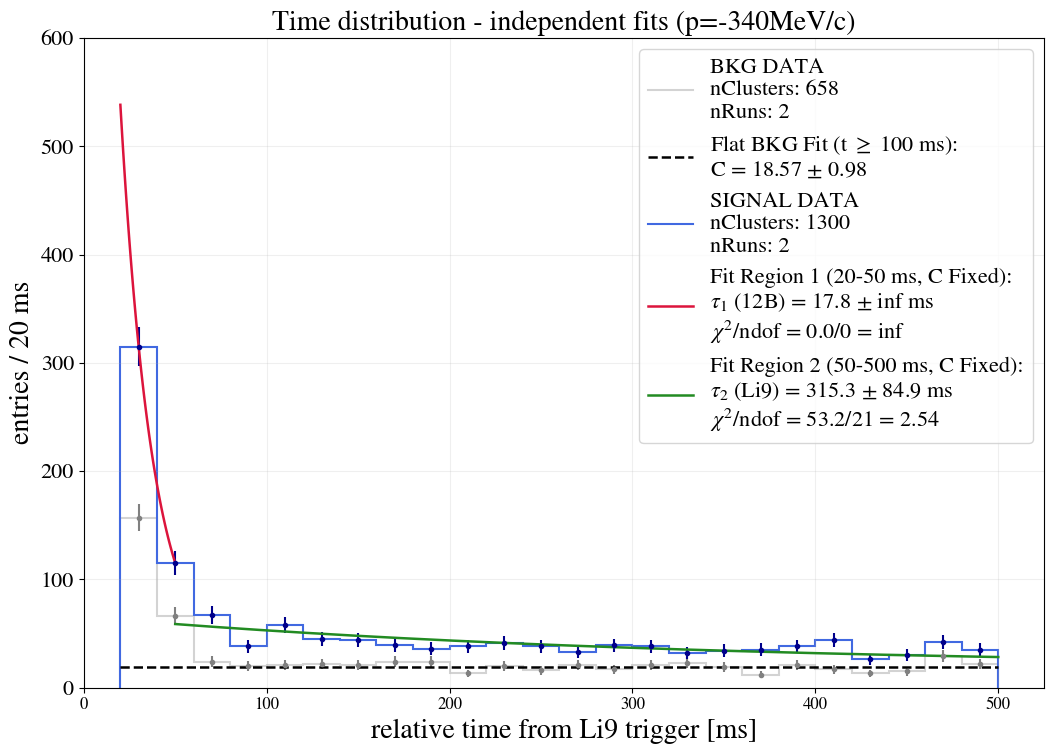

In [30]:
RUNS_340 = [1846, 1848]   #only this Beam p (from the previous step)
dfs_340_sig = []
dfs_340_bkg = []

for run in RUNS_340:
    run_folder = f"{BASE_DIR}/run{run}/processed"
    sig_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}.pkl")
    bkg_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}_BKG.pkl")
    
    if os.path.exists(sig_file):
        df_sig = pd.read_pickle(sig_file)
        if not df_sig.empty:
            df_sig['origin_run'] = run
            dfs_340_sig.append(df_sig)
            
    if os.path.exists(bkg_file):
        df_bkg = pd.read_pickle(bkg_file)
        if not df_bkg.empty:
            df_bkg['origin_run'] = run
            dfs_340_bkg.append(df_bkg)

df_sig_total = pd.concat(dfs_340_sig, ignore_index=True) if dfs_340_sig else pd.DataFrame()
df_bkg_total = pd.concat(dfs_340_bkg, ignore_index=True) if dfs_340_bkg else pd.DataFrame()


bin_width = 20 #ms
bins = np.arange(20, 500 + bin_width, bin_width)
time_column = "t_window_start_rel_ns"

times_sig_ms = (df_sig_total[time_column] / 1e6) + 20  #offset 20ms
times_bkg_ms = (df_bkg_total[time_column] / 1e6) + 20

counts_sig, bin_edges = np.histogram(times_sig_ms, bins=bins)
counts_bkg, _ = np.histogram(times_bkg_ms, bins=bins)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
errors_sig = np.sqrt(np.maximum(counts_sig, 1))
errors_bkg = np.sqrt(np.maximum(counts_bkg, 1))


# FIT 1 ---> flat BKG --> C

t_cut_bkg = 100  #excluyendo primeros bins 
mask_bkg_fit = bin_centers >= t_cut_bkg

def flat_func(t, c):
    return np.full_like(t, c)

popt_bkg, pcov_bkg = curve_fit(
    flat_func, 
    bin_centers[mask_bkg_fit], 
    counts_bkg[mask_bkg_fit], 
    sigma=errors_bkg[mask_bkg_fit],
    p0=[np.mean(counts_bkg[mask_bkg_fit])]
)
C_const = popt_bkg[0]
C_err = np.sqrt(pcov_bkg[0, 0])
#print(f"C = {C_const:.2f} ± {C_err:.2f}")

# FIT 2 --> curve fit --> 2 independientes con C fija para ambos

def exp_with_c(t, Amplitude, tau):
    return Amplitude * np.exp(-t / tau) + C_const

#region (20-50 ms)
mask_r1 = (bin_centers >= 20) & (bin_centers <= 50)

popt_r1, pcov_r1 = curve_fit(
    exp_with_c,
    bin_centers[mask_r1],
    counts_sig[mask_r1],
    sigma=errors_sig[mask_r1],
    p0=[400.0, 20.0],
    bounds=([0, 2], [5000, 200])
)
A_fit, tau1_fit = popt_r1
tau1_err = np.sqrt(pcov_r1[1, 1])

# --- CÁLCULO DE CHI2 PARA REGIÓN 1 ---
pred_r1 = exp_with_c(bin_centers[mask_r1], *popt_r1)
chi2_r1 = np.sum(((counts_sig[mask_r1] - pred_r1) / errors_sig[mask_r1])**2)
ndof_r1 = len(bin_centers[mask_r1]) - 2  # 2 parámetros libres (Amplitude, tau)


#region (50-500ms)
mask_r2 = bin_centers >= 50

popt_r2, pcov_r2 = curve_fit(
    exp_with_c,
    bin_centers[mask_r2],
    counts_sig[mask_r2],
    sigma=errors_sig[mask_r2],
    p0=[100.0, 170.0],
    bounds=([0, 30], [1000, 3000])
)
B_fit, tau2_fit = popt_r2
tau2_err = np.sqrt(pcov_r2[1, 1])

# --- CÁLCULO DE CHI2 PARA REGIÓN 2 ---
pred_r2 = exp_with_c(bin_centers[mask_r2], *popt_r2)
chi2_r2 = np.sum(((counts_sig[mask_r2] - pred_r2) / errors_sig[mask_r2])**2)
ndof_r2 = len(bin_centers[mask_r2]) - 2  # 2 parámetros libres (Amplitude, tau)


# Final PLOT

rcParams['figure.figsize'] = [11, 8]
fig, ax = plt.subplots()

#bkg
ax.stairs(counts_bkg, bin_edges, color="lightgray", linewidth=1.5, 
          label=f"BKG DATA\nnClusters: {len(df_bkg_total)}\nnRuns: {len(RUNS_340)}")
ax.errorbar(bin_centers, counts_bkg, yerr=errors_bkg, fmt="o", color="gray", markersize=3, capsize=0, ls="none")

#flat bkg (C)
t_plot_bkg = np.linspace(20, 500, 1000)
ax.plot(t_plot_bkg, flat_func(t_plot_bkg, C_const), color="black", linestyle="--", linewidth=1.8,
        label=f"Flat BKG Fit (t $\geq$ {t_cut_bkg} ms):\nC = {C_const:.2f} $\pm$ {C_err:.2f}")

#signal
ax.stairs(counts_sig, bin_edges, color="royalblue", linewidth=1.5, 
          label=f"SIGNAL DATA\nnClusters: {len(df_sig_total)}\nnRuns: {len(RUNS_340)}")
ax.errorbar(bin_centers, counts_sig, yerr=errors_sig, fmt="o", color="darkblue", markersize=3, capsize=0, ls="none")

#curve fit (20-50ms)
t_plot_r1 = np.linspace(20, 50, 100)
ax.plot(t_plot_r1, exp_with_c(t_plot_r1, *popt_r1), color="crimson", linewidth=1.8,
        label=f"Fit Region 1 (20-50 ms, C Fixed):\n$\\tau_1$ (12B) = {tau1_fit:.1f} $\pm$ {tau1_err:.1f} ms\n$\\chi^2$/ndof = {chi2_r1:.1f}/{ndof_r1} = {chi2_r1/ndof_r1:.2f}")

#curve fit (50-500ms)
t_plot_r2 = np.linspace(50, 500, 1000)
ax.plot(t_plot_r2, exp_with_c(t_plot_r2, *popt_r2), color="forestgreen", linewidth=1.8,
        label=f"Fit Region 2 (50-500 ms, C Fixed):\n$\\tau_2$ (Li9) = {tau2_fit:.1f} $\pm$ {tau2_err:.1f} ms\n$\\chi^2$/ndof = {chi2_r2:.1f}/{ndof_r2} = {chi2_r2/ndof_r2:.2f}")


ax.set_title("Time distribution - independent fits (p=-340MeV/c)")
ax.set_xlabel("relative time from Li9 trigger [ms]")
ax.set_ylabel(f"entries / {bin_width} ms")
ax.set_xlim(0, 525)
ax.set_ylim(0, 600) #fixed ylim
ax.grid(True, which="both", linestyle="-", alpha=0.2)
ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

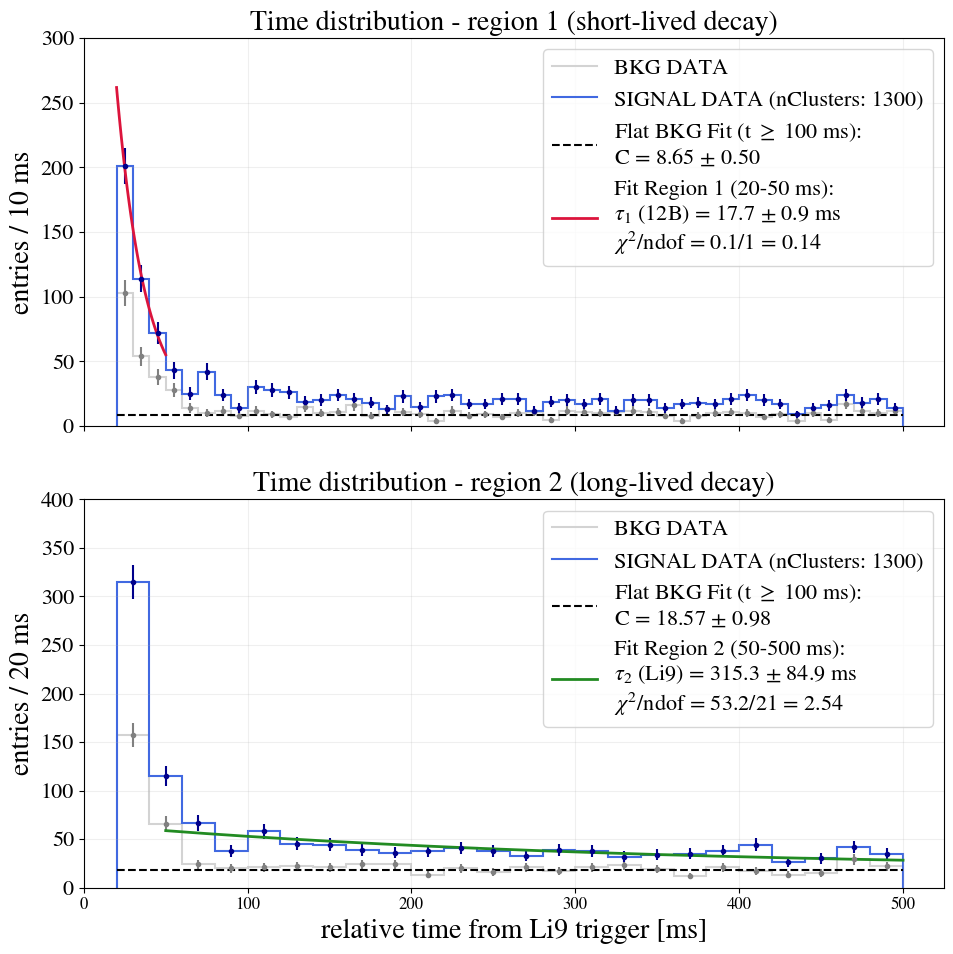

In [42]:
RUNS_340 = [1846, 1848]   #only this Beam p (from the previous step)
dfs_340_sig = []
dfs_340_bkg = []

for run in RUNS_340:
    run_folder = f"{BASE_DIR}/run{run}/processed"
    sig_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}.pkl")
    bkg_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}_BKG.pkl")
    
    if os.path.exists(sig_file):
        df_sig = pd.read_pickle(sig_file)
        if not df_sig.empty:
            df_sig['origin_run'] = run
            dfs_340_sig.append(df_sig)
            
    if os.path.exists(bkg_file):
        df_bkg = pd.read_pickle(bkg_file)
        if not df_bkg.empty:
            df_bkg['origin_run'] = run
            dfs_340_bkg.append(df_bkg)

df_sig_total = pd.concat(dfs_340_sig, ignore_index=True) if dfs_340_sig else pd.DataFrame()
df_bkg_total = pd.concat(dfs_340_bkg, ignore_index=True) if dfs_340_bkg else pd.DataFrame()

time_column = "t_window_start_rel_ns"
times_sig_ms = (df_sig_total[time_column] / 1e6) + 20  #offset 20ms
times_bkg_ms = (df_bkg_total[time_column] / 1e6) + 20


# ==========================================
# 1. PREPARACIÓN DE DATOS POR REGIÓN
# ==========================================

# --- Datos Región 1 (Ancho de bin = 10 ms) ---
bw1 = 10
bins1 = np.arange(20, 500 + bw1, bw1)
counts_sig1, bin_edges1 = np.histogram(times_sig_ms, bins=bins1)
counts_bkg1, _ = np.histogram(times_bkg_ms, bins=bins1)
bin_centers1 = (bin_edges1[:-1] + bin_edges1[1:]) / 2
errors_sig1 = np.sqrt(np.maximum(counts_sig1, 1))
errors_bkg1 = np.sqrt(np.maximum(counts_bkg1, 1))

# --- Datos Región 2 (Ancho de bin = 20 ms) ---
bw2 = 20
bins2 = np.arange(20, 500 + bw2, bw2)
counts_sig2, bin_edges2 = np.histogram(times_sig_ms, bins=bins2)
counts_bkg2, _ = np.histogram(times_bkg_ms, bins=bins2)
bin_centers2 = (bin_edges2[:-1] + bin_edges2[1:]) / 2
errors_sig2 = np.sqrt(np.maximum(counts_sig2, 1))
errors_bkg2 = np.sqrt(np.maximum(counts_bkg2, 1))


# ==========================================
# 2. CÁLCULO DE LOS AJUSTES (FITS)
# ==========================================

def flat_func(t, c):
    return np.full_like(t, c)

# ------------------------------------------
# AJUSTES PARA EL SUBPLOT 1 (Binado de 10 ms)
# ------------------------------------------
# A) Extraer C_const directamente del BKG binned a 10ms para t >= 100ms
mask_bkg_fit1 = bin_centers1 >= 100
popt_bkg1, pcov_bkg1 = curve_fit(
    flat_func, bin_centers1[mask_bkg_fit1], counts_bkg1[mask_bkg_fit1], 
    sigma=errors_bkg1[mask_bkg_fit1], p0=[np.mean(counts_bkg1[mask_bkg_fit1])]
)
C_const_r1 = popt_bkg1[0]
C_err_r1 = np.sqrt(pcov_bkg1[0, 0])

# B) Fit Exponencial Región 1 (20-50 ms) con su respectiva C fija
mask_r1 = (bin_centers1 >= 20) & (bin_centers1 <= 50)

def exp_with_c_r1(t, Amplitude, tau):
    return Amplitude * np.exp(-t / tau) + C_const_r1

popt_r1, pcov_r1 = curve_fit(
    exp_with_c_r1, bin_centers1[mask_r1], counts_sig1[mask_r1], sigma=errors_sig1[mask_r1],
    p0=[400.0, 20.0], bounds=([0, 2], [5000, 200])
)
A_fit, tau1_fit = popt_r1
tau1_err = np.sqrt(pcov_r1[1, 1])

pred_r1 = exp_with_c_r1(bin_centers1[mask_r1], *popt_r1)
chi2_r1 = np.sum(((counts_sig1[mask_r1] - pred_r1) / errors_sig1[mask_r1])**2)
ndof_r1 = len(bin_centers1[mask_r1]) - 2


# ------------------------------------------
# AJUSTES PARA EL SUBPLOT 2 (Binado de 20 ms)
# ------------------------------------------
# A) Extraer C_const directamente del BKG binned a 20ms para t >= 100ms
mask_bkg_fit2 = bin_centers2 >= 100
popt_bkg2, pcov_bkg2 = curve_fit(
    flat_func, bin_centers2[mask_bkg_fit2], counts_bkg2[mask_bkg_fit2], 
    sigma=errors_bkg2[mask_bkg_fit2], p0=[np.mean(counts_bkg2[mask_bkg_fit2])]
)
C_const_r2 = popt_bkg2[0]
C_err_r2 = np.sqrt(pcov_bkg2[0, 0])

# B) Fit Exponencial Región 2 (50-500 ms) con su respectiva C fija
mask_r2 = bin_centers2 >= 50

def exp_with_c_r2(t, Amplitude, tau):
    return Amplitude * np.exp(-t / tau) + C_const_r2

popt_r2, pcov_r2 = curve_fit(
    exp_with_c_r2, bin_centers2[mask_r2], counts_sig2[mask_r2], sigma=errors_sig2[mask_r2],
    p0=[100.0, 170.0], bounds=([0, 30], [1000, 3000])
)
B_fit, tau2_fit = popt_r2
tau2_err = np.sqrt(pcov_r2[1, 1])

pred_r2 = exp_with_c_r2(bin_centers2[mask_r2], *popt_r2)
chi2_r2 = np.sum(((counts_sig2[mask_r2] - pred_r2) / errors_sig2[mask_r2])**2)
ndof_r2 = len(bin_centers2[mask_r2]) - 2


# ==========================================
# 3. GENERACIÓN DEL PLOT (2 SUBPLOTS)
# ==========================================
rcParams['figure.figsize'] = [10, 10]
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

t_range = np.linspace(20, 500, 1000)

# ------------------------------------------
# SUBPLOT 1: REGIÓN 1 (Bines de 10 ms)
# ------------------------------------------
ax1.stairs(counts_bkg1, bin_edges1, color="lightgray", linewidth=1.5, label="BKG DATA")
ax1.errorbar(bin_centers1, counts_bkg1, yerr=errors_bkg1, fmt="o", color="gray", markersize=3, ls="none")

ax1.stairs(counts_sig1, bin_edges1, color="royalblue", linewidth=1.5, label=f"SIGNAL DATA (nClusters: {len(df_sig_total)})")
ax1.errorbar(bin_centers1, counts_sig1, yerr=errors_sig1, fmt="o", color="darkblue", markersize=3, ls="none")

# Línea de fondo calculada sobre la muestra BKG (10ms, t >= 100ms)
ax1.plot(t_range, flat_func(t_range, C_const_r1), color="black", linestyle="--", linewidth=1.5,
         label=f"Flat BKG Fit (t $\geq$ 100 ms):\nC = {C_const_r1:.2f} $\pm$ {C_err_r1:.2f}")

# Ajuste exponencial R1 (20-50 ms)
t_plot_r1 = np.linspace(20, 50, 100)
ax1.plot(t_plot_r1, exp_with_c_r1(t_plot_r1, *popt_r1), color="crimson", linewidth=2,
         label=f"Fit Region 1 (20-50 ms):\n$\\tau_1$ (12B) = {tau1_fit:.1f} $\pm$ {tau1_err:.1f} ms\n$\\chi^2$/ndof = {chi2_r1:.1f}/{ndof_r1} = {chi2_r1/ndof_r1:.2f}")

ax1.set_title("Time distribution - region 1 (short-lived decay)")
ax1.set_ylabel(f"entries / {bw1} ms")
ax1.set_ylim(0, 300) 
ax1.grid(True, which="both", linestyle="-", alpha=0.2)
ax1.legend(loc="upper right", frameon=True)


# ------------------------------------------
# SUBPLOT 2: REGIÓN 2 (Bines de 20 ms)
# ------------------------------------------
ax2.stairs(counts_bkg2, bin_edges2, color="lightgray", linewidth=1.5, label="BKG DATA")
ax2.errorbar(bin_centers2, counts_bkg2, yerr=errors_bkg2, fmt="o", color="gray", markersize=3, ls="none")

ax2.stairs(counts_sig2, bin_edges2, color="royalblue", linewidth=1.5, label=f"SIGNAL DATA (nClusters: {len(df_sig_total)})")
ax2.errorbar(bin_centers2, counts_sig2, yerr=errors_sig2, fmt="o", color="darkblue", markersize=3, ls="none")

# Línea de fondo calculada sobre la muestra BKG (20ms, t >= 100ms)
ax2.plot(t_range, flat_func(t_range, C_const_r2), color="black", linestyle="--", linewidth=1.5,
         label=f"Flat BKG Fit (t $\geq$ 100 ms):\nC = {C_const_r2:.2f} $\pm$ {C_err_r2:.2f}")

# Ajuste exponencial R2 (50-500 ms)
t_plot_r2 = np.linspace(50, 500, 1000)
ax2.plot(t_plot_r2, exp_with_c_r2(t_plot_r2, *popt_r2), color="forestgreen", linewidth=2,
         label=f"Fit Region 2 (50-500 ms):\n$\\tau_2$ (Li9) = {tau2_fit:.1f} $\pm$ {tau2_err:.1f} ms\n$\\chi^2$/ndof = {chi2_r2:.1f}/{ndof_r2} = {chi2_r2/ndof_r2:.2f}")

ax2.set_title("Time distribution - region 2 (long-lived decay)")
ax2.set_xlabel("relative time from Li9 trigger [ms]")
ax2.set_ylabel(f"entries / {bw2} ms")
ax2.set_xlim(0, 525)
ax2.set_ylim(0, 400) 
ax2.grid(True, which="both", linestyle="-", alpha=0.2)
ax2.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

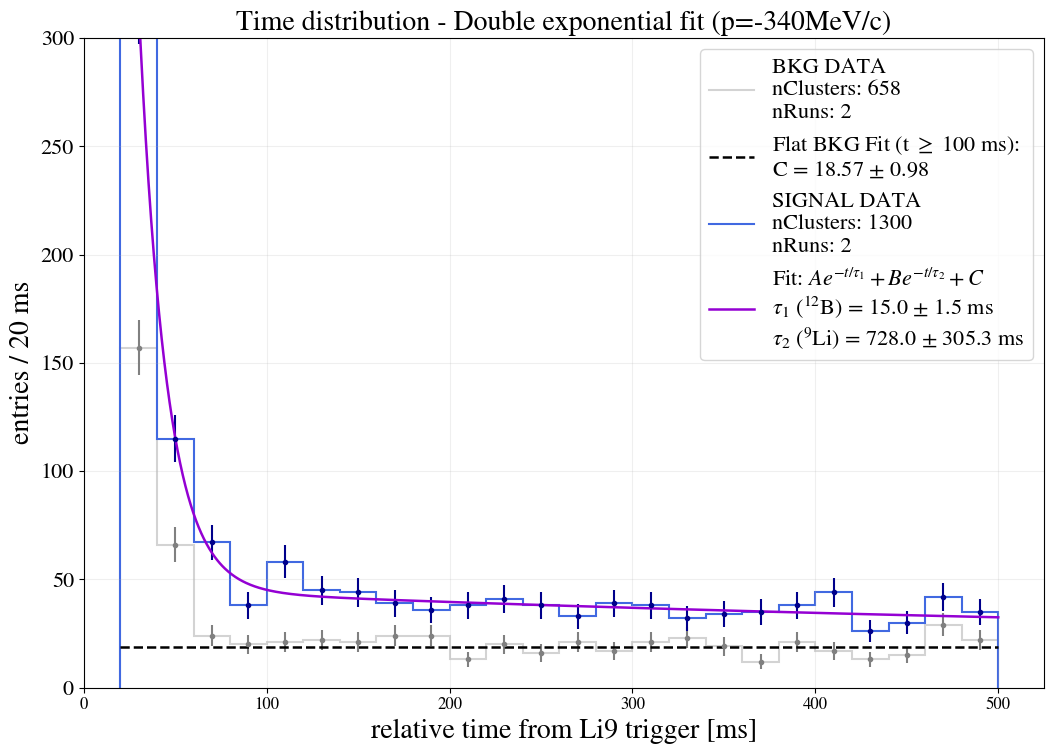

In [10]:
bin_width = 20  
bins = np.arange(20, 500 + bin_width, bin_width)


#GLOBLA FIT with fixed C

def double_exp_with_c(t, A, tau1, B, tau2):
    return A * np.exp(-t / tau1) + B * np.exp(-t / tau2) + C_const

#all bins within the entire range 
mask_global = (bin_centers >= 20) & (bin_centers <= 500)

#initial seeds: p0 = [A, tau1, B, tau2]
p0_global = [400.0, 20.0, 100.0, 170.0]
bounds_global = (
    [0, 2, 0, 30],         #inf lim
    [5000, 200, 1000, 3000] #sup lim
)

popt_g, pcov_g = curve_fit(
    double_exp_with_c,
    bin_centers[mask_global],
    counts_sig[mask_global],
    sigma=errors_sig[mask_global],
    p0=p0_global,
    bounds=bounds_global
)

#parámetros y sus errores asociados (raíz de la diagonal de la covarianza)
A_fit, tau1_fit, B_fit, tau2_fit = popt_g
A_err, tau1_err, B_err, tau2_err = np.sqrt(np.diag(pcov_g))

#print(f"12B --> Amplitud A = {A_fit:.1f} ± {A_err:.1f} | tau_1 = {tau1_fit:.1f} ± {tau1_err:.1f} ms")
#print(f"Li9 --> Amplitud B = {B_fit:.1f} ± {B_err:.1f} | tau_2 = {tau2_fit:.1f} ± {tau2_err:.1f} ms")

# final PLOT

rcParams['figure.figsize'] = [11, 8]
fig, ax = plt.subplots()

#bkg
ax.stairs(counts_bkg, bin_edges, color="lightgray", linewidth=1.5, 
          label=f"BKG DATA\nnClusters: {len(df_bkg_total)}\nnRuns: {len(RUNS_340)}")
ax.errorbar(bin_centers, counts_bkg, yerr=errors_bkg, fmt="o", color="gray", markersize=3, capsize=0, ls="none")

#C
t_plot_bkg = np.linspace(20, 500, 1000)
ax.plot(t_plot_bkg, flat_func(t_plot_bkg, C_const), color="black", linestyle="--", linewidth=1.8,
        label=f"Flat BKG Fit (t $\geq$ {t_cut_bkg} ms):\nC = {C_const:.2f} $\pm$ {C_err:.2f}")

# signal
ax.stairs(counts_sig, bin_edges, color="royalblue", linewidth=1.5, 
          label=f"SIGNAL DATA\nnClusters: {len(df_sig_total)}\nnRuns: {len(RUNS_340)}")
ax.errorbar(bin_centers, counts_sig, yerr=errors_sig, fmt="o", color="darkblue", markersize=3, capsize=0, ls="none")


#doble exponential fit for the entire range
t_plot_global = np.linspace(20, 500, 1000)
label_fit = (
    f"Fit: $A e^{{-t/\\tau_1}} + B e^{{-t/\\tau_2}} + C$\n"
    f"$\\tau_1$ ($^{{12}}$B) = {tau1_fit:.1f} $\pm$ {tau1_err:.1f} ms\n"
    f"$\\tau_2$ ($^{9}$Li) = {tau2_fit:.1f} $\pm$ {tau2_err:.1f} ms"
)
ax.plot(t_plot_global, double_exp_with_c(t_plot_global, *popt_g), color="darkviolet", linewidth=1.8, label=label_fit)


ax.set_title("Time distribution - Double exponential fit (p=-340MeV/c)")
ax.set_xlabel("relative time from Li9 trigger [ms]")
ax.set_ylabel(f"entries / {bin_width} ms")
ax.set_xlim(0, 525)
ax.set_ylim(0, 300) # Mantengo tu límite superior a 300 para limpieza visual

ax.grid(True, which="both", linestyle="-", alpha=0.2)
ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_302814/3938859133.py:114: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(inv_hessian))


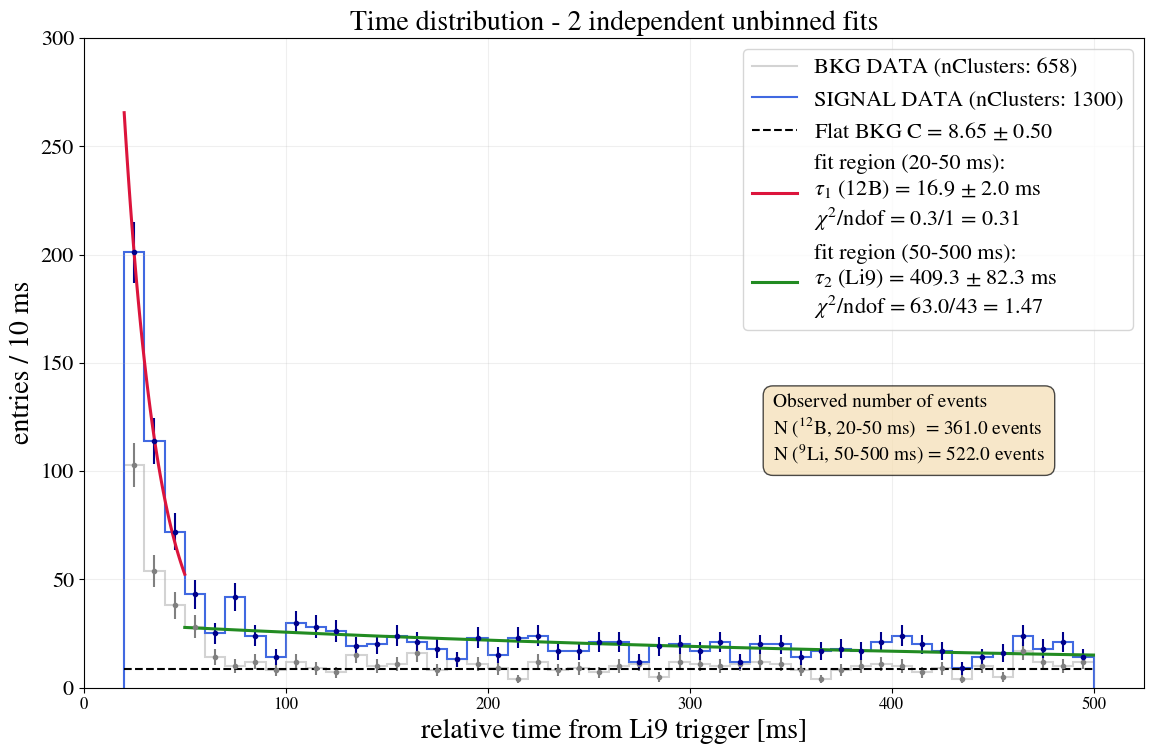

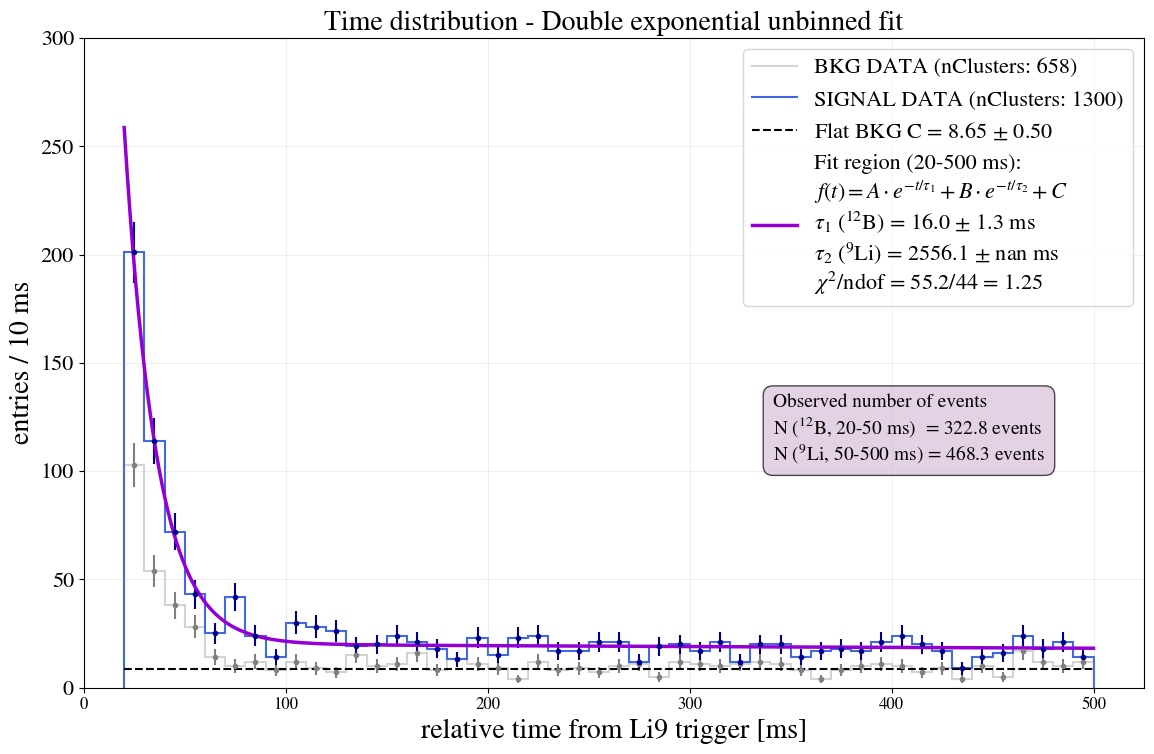

In [23]:
RUNS_340 = [1846, 1848]   # only this Beam p (from the previous step)
dfs_340_sig = []
dfs_340_bkg = []

for run in RUNS_340:
    run_folder = f"{BASE_DIR}/run{run}/processed"
    sig_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}.pkl")
    bkg_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}_BKG.pkl")
    
    if os.path.exists(sig_file):
        df_sig = pd.read_pickle(sig_file)
        if not df_sig.empty:
            df_sig['origin_run'] = run
            dfs_340_sig.append(df_sig)
            
    if os.path.exists(bkg_file):
        df_bkg = pd.read_pickle(bkg_file)
        if not df_bkg.empty:
            df_bkg['origin_run'] = run
            dfs_340_bkg.append(df_bkg)

df_sig_total = pd.concat(dfs_340_sig, ignore_index=True) if dfs_340_sig else pd.DataFrame()
df_bkg_total = pd.concat(dfs_340_bkg, ignore_index=True) if dfs_340_bkg else pd.DataFrame()


bin_width = 10 # ms
bins = np.arange(20, 500 + bin_width, bin_width)
time_column = "t_window_start_rel_ns"

times_sig_ms = (df_sig_total[time_column] / 1e6) + 20  # offset 20ms
times_bkg_ms = (df_bkg_total[time_column] / 1e6) + 20

counts_sig, bin_edges = np.histogram(times_sig_ms, bins=bins)
counts_bkg, _ = np.histogram(times_bkg_ms, bins=bins)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
errors_sig = np.sqrt(np.maximum(counts_sig, 1))
errors_bkg = np.sqrt(np.maximum(counts_bkg, 1))


# ==========================================
# 1. FIT PREVIO DE FONDO PLANO (C)
# ==========================================
t_cut_bkg = 100  
mask_bkg_fit = bin_centers >= t_cut_bkg

def flat_func(t, c):
    return np.full_like(t, c)

popt_bkg, pcov_bkg = curve_fit(
    flat_func, 
    bin_centers[mask_bkg_fit], 
    counts_bkg[mask_bkg_fit], 
    sigma=errors_bkg[mask_bkg_fit],
    p0=[np.mean(counts_bkg[mask_bkg_fit])]
)
C_const = popt_bkg[0]
C_err = np.sqrt(pcov_bkg[0, 0])


# ==========================================
# 2. DEFINICIÓN DE FUNCIONES PARA AJUSTES UNBINNED
# ==========================================

# Verosimilitud logarítmica negativa extendida (1 Exponencial + C)
def extended_nll(params, times, t_min, t_max, C, dt):
    Amp, tau = params
    if Amp < 0 or tau <= 0:
        return 1e10
    
    n_exp = (Amp * tau / dt) * (np.exp(-t_min / tau) - np.exp(-t_max / tau)) + (C / dt) * (t_max - t_min)
    lambda_i = (Amp / dt) * np.exp(-times / tau) + (C / dt)
    
    if np.any(lambda_i <= 0):
        return 1e10
    return n_exp - np.sum(np.log(lambda_i))

# Verosimilitud logarítmica negativa extendida GLOBAL (Doble Exponencial + C)
def extended_nll_global(params, times, t_min, t_max, C, dt):
    Amp1, tau1, Amp2, tau2 = params
    if Amp1 < 0 or tau1 <= 0 or Amp2 < 0 or tau2 <= 0:
        return 1e10
    
    n_exp = ((Amp1 * tau1 / dt) * (np.exp(-t_min / tau1) - np.exp(-t_max / tau1)) + 
             (Amp2 * tau2 / dt) * (np.exp(-t_min / tau2) - np.exp(-t_max / tau2)) + 
             (C / dt) * (t_max - t_min))
    
    lambda_i = (Amp1 / dt) * np.exp(-times / tau1) + (Amp2 / dt) * np.exp(-times / tau2) + (C / dt)
    
    if np.any(lambda_i <= 0):
        return 1e10
    return n_exp - np.sum(np.log(lambda_i))

# Función para calcular errores numéricos usando la Hessiana
def compute_mle_errors(f, x, args):
    n = len(x)
    hessian = np.zeros((n, n))
    eps = 1e-4 * np.maximum(np.abs(x), 1e-3)
    for i in range(n):
        for j in range(n):
            if i == j:
                x_plus, x_minus = np.array(x, dtype=float), np.array(x, dtype=float)
                x_plus[i] += eps[i]; x_minus[i] -= eps[i]
                hessian[i, i] = (f(x_plus, *args) - 2 * f(x, *args) + f(x_minus, *args)) / (eps[i] ** 2)
            else:
                x_pp, x_pm, x_mp, x_mm = [np.array(x, dtype=float) for _ in range(4)]
                x_pp[i] += eps[i]; x_pp[j] += eps[j]
                x_pm[i] += eps[i]; x_pm[j] -= eps[j]
                x_mp[i] -= eps[i]; x_mp[j] += eps[j]
                x_mm[i] -= eps[i]; x_mm[j] -= eps[j]
                hessian[i, j] = (f(x_pp, *args) - f(x_pm, *args) - f(x_mp, *args) + f(x_mm, *args)) / (4 * eps[i] * eps[j])
    try:
        inv_hessian = np.linalg.inv(hessian)
        return np.sqrt(np.diag(inv_hessian))
    except np.linalg.LinAlgError:
        return np.zeros_like(x)

# Función analítica para calcular los eventos netos (Área de la señal integrada)
def get_net_events(Amp, tau, t1, t2, dt):
    return (Amp * tau / dt) * (np.exp(-t1 / tau) - np.exp(-t2 / tau))


# ==========================================
# 3. EJECUCIÓN DE LOS AJUSTES UNBINNED
# ==========================================

# --- AJUSTES INDEPENDIENTES ---
# Región 1 (20-50 ms)
t_min1, t_max1 = 20.0, 50.0
times_r1 = times_sig_ms[(times_sig_ms >= t_min1) & (times_sig_ms <= t_max1)].values
res_r1 = minimize(extended_nll, x0=[400.0, 20.0], args=(times_r1, t_min1, t_max1, C_const, bin_width),
                  bounds=[(0, 5000), (2, 200)], method='L-BFGS-B')
A_fit, tau1_fit = res_r1.x
A_err, tau1_err = compute_mle_errors(extended_nll, res_r1.x, (times_r1, t_min1, t_max1, C_const, bin_width))

# Región 2 (50-500 ms)
t_min2, t_max2 = 50.0, 500.0
times_r2 = times_sig_ms[(times_sig_ms >= t_min2) & (times_sig_ms <= t_max2)].values
res_r2 = minimize(extended_nll, x0=[100.0, 170.0], args=(times_r2, t_min2, t_max2, C_const, bin_width),
                  bounds=[(0, 1000), (30, 3000)], method='L-BFGS-B')
B_fit, tau2_fit = res_r2.x
B_err, tau2_err = compute_mle_errors(extended_nll, res_r2.x, (times_r2, t_min2, t_max2, C_const, bin_width))

# Integrales independientes
N_indep_r1 = get_net_events(A_fit, tau1_fit, 20, 50, bin_width)
N_indep_r2 = get_net_events(B_fit, tau2_fit, 50, 500, bin_width)


# --- AJUSTE GLOBAL (Doble Exponencial) ---
t_min_g, t_max_g = 20.0, 500.0
times_global = times_sig_ms[(times_sig_ms >= t_min_g) & (times_sig_ms <= t_max_g)].values
res_global = minimize(extended_nll_global, x0=[400.0, 20.0, 100.0, 170.0], 
                      args=(times_global, t_min_g, t_max_g, C_const, bin_width),
                      bounds=[(0, 5000), (2, 200), (0, 1000), (30, 3000)], method='L-BFGS-B')
A_g, tau1_g, B_g, tau2_g = res_global.x
errors_g = compute_mle_errors(extended_nll_global, res_global.x, (times_global, t_min_g, t_max_g, C_const, bin_width))
A_g_err, tau1_g_err, B_g_err, tau2_g_err = errors_g

# Integrales del ajuste global en sus respectivas regiones de interés
N_global_r1 = get_net_events(A_g, tau1_g, 20, 50, bin_width)
N_global_r2 = get_net_events(B_g, tau2_g, 50, 500, bin_width)


# ==========================================
# 4. CÁLCULO DE CHI2 PARA CADA CASO
# ==========================================
def exp_with_c(t, Amplitude, tau):
    return Amplitude * np.exp(-t / tau) + C_const

def double_exp_with_c(t, Amp1, tau1, Amp2, tau2):
    return Amp1 * np.exp(-t / tau1) + Amp2 * np.exp(-t / tau2) + C_const

# Chi2 R1 Independiente (rango 20-50 ms)
mask_chi2_r1 = (bin_centers >= 20) & (bin_centers <= 50)
exp_r1 = exp_with_c(bin_centers[mask_chi2_r1], A_fit, tau1_fit)
chi2_r1 = np.sum(((counts_sig[mask_chi2_r1] - exp_r1) / errors_sig[mask_chi2_r1])**2)
ndof_r1 = len(bin_centers[mask_chi2_r1]) - 2

# Chi2 R2 Independiente (rango 50-500 ms)
mask_chi2_r2 = (bin_centers >= 50) & (bin_centers <= 500)
exp_r2 = exp_with_c(bin_centers[mask_chi2_r2], B_fit, tau2_fit)
chi2_r2 = np.sum(((counts_sig[mask_chi2_r2] - exp_r2) / errors_sig[mask_chi2_r2])**2)
ndof_r2 = len(bin_centers[mask_chi2_r2]) - 2

# Chi2 Ajuste Global (rango completo 20-500 ms)
mask_chi2_g = (bin_centers >= 20) & (bin_centers <= 500)
exp_g = double_exp_with_c(bin_centers[mask_chi2_g], A_g, tau1_g, B_g, tau2_g)
chi2_g = np.sum(((counts_sig[mask_chi2_g] - exp_g) / errors_sig[mask_chi2_g])**2)
ndof_g = len(bin_centers[mask_chi2_g]) - 4


# ==========================================
# 5. GENERACIÓN DE PLOTS
# ==========================================
rcParams['figure.figsize'] = [12, 8]

# ------------------------------------------
# PLOT 1: PLOT DE AJUSTES INDEPENDIENTES
# ------------------------------------------
fig1, ax1 = plt.subplots()

# Histogramas base
ax1.stairs(counts_bkg, bin_edges, color="lightgray", linewidth=1.5, label=f"BKG DATA (nClusters: {len(df_bkg_total)})")
ax1.errorbar(bin_centers, counts_bkg, yerr=errors_bkg, fmt="o", color="gray", markersize=3, capsize=0, ls="none")
ax1.stairs(counts_sig, bin_edges, color="royalblue", linewidth=1.5, label=f"SIGNAL DATA (nClusters: {len(df_sig_total)})")
ax1.errorbar(bin_centers, counts_sig, yerr=errors_sig, fmt="o", color="darkblue", markersize=3, capsize=0, ls="none")

# Línea base de Fondo (Añadido error de C)
t_range = np.linspace(20, 500, 1000)
ax1.plot(t_range, flat_func(t_range, C_const), color="black", linestyle="--", linewidth=1.5, label=f"Flat BKG C = {C_const:.2f} $\pm$ {C_err:.2f}")

# Curva R1
t_plot_r1 = np.linspace(20, 50, 100)
ax1.plot(t_plot_r1, exp_with_c(t_plot_r1, A_fit, tau1_fit), color="crimson", linewidth=2.2,
        label=f"fit region (20-50 ms):\n$\\tau_1$ (12B) = {tau1_fit:.1f} $\pm$ {tau1_err:.1f} ms\n$\\chi^2$/ndof = {chi2_r1:.1f}/{ndof_r1} = {chi2_r1/ndof_r1:.2f}")

# Curva R2
t_plot_r2 = np.linspace(50, 500, 1000)
ax1.plot(t_plot_r2, exp_with_c(t_plot_r2, B_fit, tau2_fit), color="forestgreen", linewidth=2.2,
        label=f"fit region (50-500 ms):\n$\\tau_2$ (Li9) = {tau2_fit:.1f} $\pm$ {tau2_err:.1f} ms\n$\\chi^2$/ndof = {chi2_r2:.1f}/{ndof_r2} = {chi2_r2/ndof_r2:.2f}")

# Cuadro de texto para las Integrales del Plot 1
text_boxes1 = (
    f"Observed number of events\n"
    f"N ($^{{12}}$B, 20-50 ms)  = {N_indep_r1:.1f} events\n"
    f"N ($^{9}$Li, 50-500 ms) = {N_indep_r2:.1f} events"
)
ax1.text(0.65, 0.35, text_boxes1, transform=ax1.transAxes, fontsize=14, bbox=dict(boxstyle="round,pad=0.5", facecolor="wheat", alpha=0.7))

ax1.set_title("Time distribution - 2 independent unbinned fits")
ax1.set_xlabel("relative time from Li9 trigger [ms]")
ax1.set_ylabel(f"entries / {bin_width} ms")
ax1.set_xlim(0, 525)
ax1.set_ylim(0, 300)
ax1.grid(True, which="both", linestyle="-", alpha=0.2)
ax1.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()


# ------------------------------------------
# PLOT 2: PLOT DE AJUSTE GLOBAL (DOBLE EXPONENCIAL)
# ------------------------------------------
fig2, ax2 = plt.subplots()

# Histogramas base
ax2.stairs(counts_bkg, bin_edges, color="lightgray", linewidth=1.5, label=f"BKG DATA (nClusters: {len(df_bkg_total)})")
ax2.errorbar(bin_centers, counts_bkg, yerr=errors_bkg, fmt="o", color="gray", markersize=3, capsize=0, ls="none")
ax2.stairs(counts_sig, bin_edges, color="royalblue", linewidth=1.5, label=f"SIGNAL DATA (nClusters: {len(df_sig_total)})")
ax2.errorbar(bin_centers, counts_sig, yerr=errors_sig, fmt="o", color="darkblue", markersize=3, capsize=0, ls="none")
# Línea base de Fondo (Añadido error de C)
ax2.plot(t_range, flat_func(t_range, C_const), color="black", linestyle="--", linewidth=1.5, label=f"Flat BKG C = {C_const:.2f} $\pm$ {C_err:.2f}")

# Curva Global Doble Exponencial (Añadida la fórmula matemática del fit)
label_g = (
    f"Fit region (20-500 ms):\n"
    f"$f(t) = A \\cdot e^{{-t/\\tau_1}} + B \\cdot e^{{-t/\\tau_2}} + C$\n"
    f"$\\tau_1$ ($^{{12}}$B) = {tau1_g:.1f} $\pm$ {tau1_g_err:.1f} ms\n"
    f"$\\tau_2$ ($^{9}$Li) = {tau2_g:.1f} $\pm$ {tau2_g_err:.1f} ms\n"
    f"$\\chi^2$/ndof = {chi2_g:.1f}/{ndof_g} = {chi2_g/ndof_g:.2f}"
)
ax2.plot(t_range, double_exp_with_c(t_range, A_g, tau1_g, B_g, tau2_g), color="darkviolet", linewidth=2.5, label=label_g)

# Cuadro de texto para las Integrales del Plot 2
text_boxes2 = (
    f"Observed number of events\n"
    f"N ($^{{12}}$B, 20-50 ms)  = {N_global_r1:.1f} events\n"
    f"N ($^{9}$Li, 50-500 ms) = {N_global_r2:.1f} events"
)
ax2.text(0.65, 0.35, text_boxes2, transform=ax2.transAxes, fontsize=14, bbox=dict(boxstyle="round,pad=0.5", facecolor="thistle", alpha=0.7))

ax2.set_title("Time distribution - Double exponential unbinned fit")
ax2.set_xlabel("relative time from Li9 trigger [ms]")
ax2.set_ylabel(f"entries / {bin_width} ms")
ax2.set_xlim(0, 525)
ax2.set_ylim(0, 300)
ax2.grid(True, which="both", linestyle="-", alpha=0.2)
ax2.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

In [45]:
beam_p = "-340 MeV/c"

#signal
# Número de spills únicos reales (run + spill_id)
if not df_sig_total.empty:
    n_spills_sig = df_sig_total.groupby(['origin_run', 'spill_id']).ngroups
    total_events_sig = len(df_sig_total)
    events_sig_r1 = len(df_sig_total[(times_sig_ms >= 20) & (times_sig_ms <= 50)])
    events_sig_r2 = len(df_sig_total[(times_sig_ms >= 50) & (times_sig_ms <= 500)])
    
    rate_sig_r1 = events_sig_r1 / n_spills_sig
    rate_sig_r2 = events_sig_r2 / n_spills_sig
else:
    n_spills_sig, total_events_sig, events_sig_r1, events_sig_r2 = 0, 0, 0, 0
    rate_sig_r1, rate_sig_r2 = 0.0, 0.0

# BKG
if not df_bkg_total.empty:
    n_spills_bkg = df_bkg_total.groupby(['origin_run', 'spill_id']).ngroups
    total_events_bkg = len(df_bkg_total)
    events_bkg_r1 = len(df_bkg_total[(times_bkg_ms >= 20) & (times_bkg_ms <= 50)])
    events_bkg_r2 = len(df_bkg_total[(times_bkg_ms >= 50) & (times_bkg_ms <= 500)])
    
    rate_bkg_r1 = events_bkg_r1 / n_spills_bkg
    rate_bkg_r2 = events_bkg_r2 / n_spills_bkg
else:
    n_spills_bkg, total_events_bkg, events_bkg_r1, events_bkg_r2 = 0, 0, 0, 0
    rate_bkg_r1, rate_bkg_r2 = 0.0, 0.0


# DF
summary_data = {
    "Beam p": [beam_p],
    
    #columns SIGNAL_SAMPLE
    "Sig N Spills": [n_spills_sig],
    "Sig Total Candidates": [total_events_sig],
    "Sig Evts (20-50ms)/Spill": [round(rate_sig_r1, 5)],
    "Sig Evts (50-500ms)/Spill": [round(rate_sig_r2, 5)],
    
    # columns BKG_SAMPLE
    "Bkg N Spills": [n_spills_bkg],
    "Bkg Total Candidates": [total_events_bkg],
    "Bkg Evts (20-50ms)/Spill": [round(rate_bkg_r1, 5)],
    "Bkg Evts (50-500ms)/Spill": [round(rate_bkg_r2, 5)]
}

df_summary = pd.DataFrame(summary_data)

# Mostrar la tabla formateada en el Notebook
from IPython.display import display
display(df_summary)

,Beam p,Sig N Spills,Sig Total Candidates,Sig Evts (20-50ms)/Spill,Sig Evts (50-500ms)/Spill,Bkg N Spills,Bkg Total Candidates,Bkg Evts (20-50ms)/Spill,Bkg Evts (50-500ms)/Spill
0,-340 MeV/c,308,1300,1.25649,2.96429,158,658,1.23418,2.93038


In [43]:
#TABLE!

observed_summary = []

# Combine both momentum dataframes into a single list to iterate run-by-run
all_final_dfs = dfs_340 + dfs_260

for df_run in all_final_dfs:
    if df_run.empty:
        continue
        
    run_id = df_run['origin_run'].iloc[0]
    momentum = get_beam_momentum(run_id)
    
    total_final_clusters = len(df_run)
    
    time_ms_corrected = (df_run["t_window_start_rel_ns"] / 1e6) + 20
    
    #clusters in (20-50ms)
    obs_20_50 = ((time_ms_corrected >= 20) & (time_ms_corrected <= 50)).sum()
    
    #(50-500ms)
    obs_50_500 = ((time_ms_corrected > 50) & (time_ms_corrected <= 500)).sum()
   
    observed_summary.append({
        "Run Number": f"Run {run_id}",
        "Beam p [MeV/c]": momentum,
        "Total final clusters": total_final_clusters,
        "Events obs (20-50ms)": obs_20_50,
        "Events obs (50-500ms)": obs_50_500
    })


df_observed_table = pd.DataFrame(observed_summary)

df_observed_table = df_observed_table.sort_values(by="Run Number").reset_index(drop=True)

print("=" * 95)
print("                          BACKGROUNDFINAL OBSERVED SUMMARY TABLE")
print("=" * 95)
print(df_observed_table.to_string(index=False))
print("=" * 95)

                          BACKGROUNDFINAL OBSERVED SUMMARY TABLE
Run Number Beam p [MeV/c]  Total final clusters  Events obs (20-50ms)  Events obs (50-500ms)
  Run 1846     -340 MeV/c                   362                   107                    255
  Run 1848     -340 MeV/c                   296                    88                    208
  Run 1928     -260 MeV/c                   387                    45                    342
  Run 1930     -260 MeV/c                   819                   201                    618
  Run 1932     -260 MeV/c                   747                   214                    533
  Run 1934     -260 MeV/c                   390                    74                    316
  Run 1935     -260 MeV/c                   402                    60                    342
  Run 1936     -260 MeV/c                   256                    19                    237
  Run 1937     -260 MeV/c                   437                    62                    375
  Run